# Home/Work Detection Validation

This notebook validates the HoWDe home/work detection results from Swedish GPS data.

**Input**: `dbs/home_work/hw_{batch}.parquet` from home_work_detection.py

**Validation Checks**:
1. Location type distribution (H/W/O percentages)
2. Home detection rate (target: >= 90%)
3. Work detection rate (target: >= 50%)
4. Temporal patterns (H at night, W during day)
5. Spatial reasonableness (H near residential, W in commercial)
6. Sample user trajectories

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Paths
ROOT_DIR = Path('/workspace')
HW_DIR = ROOT_DIR / 'dbs' / 'home_work'
STOPS_DIR = ROOT_DIR / 'dbs' / 'stops'

print(f"Home/Work directory: {HW_DIR}")
print(f"Available files: {list(HW_DIR.glob('*.parquet'))}")

Home/Work directory: /workspace/dbs/home_work
Available files: [PosixPath('/workspace/dbs/home_work/hw_0.parquet')]


## 1. Load Data

In [2]:
# Load a single batch for exploration (or merged file if available)
merged_file = HW_DIR / 'hw_all.parquet'
batch_file = HW_DIR / 'hw_0.parquet'

if merged_file.exists():
    print("Loading merged file...")
    df = pd.read_parquet(merged_file)
elif batch_file.exists():
    print("Loading batch 0...")
    df = pd.read_parquet(batch_file)
else:
    raise FileNotFoundError("No home/work files found. Run home_work_detection.py first.")

print(f"\nLoaded {len(df):,} stops")
print(f"Unique devices: {df['device_aid'].nunique():,}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDtypes:")
print(df.dtypes)

Loading batch 0...

Loaded 9,173,381 stops
Unique devices: 129,004

Columns: ['device_aid', 'loc', 'start', 'end', 'country', 'date', 'location_type', 'detect_H_loc', 'detect_W_loc', 'latitude', 'longitude', 'batch']

Dtypes:
device_aid                  str
loc                         str
start                     int64
end                       int64
country                     str
date             datetime64[ns]
location_type               str
detect_H_loc                str
detect_W_loc                str
latitude                float64
longitude               float64
batch                     int32
dtype: object


In [ ]:
# Sample data
df.head()

## 2. Location Type Distribution

In [4]:
# Overall distribution of location types
type_counts = df['location_type'].value_counts()
type_pcts = df['location_type'].value_counts(normalize=True) * 100

print("Location Type Distribution:")
print("="*40)
for t in ['H', 'W', 'O']:
    if t in type_counts.index:
        print(f"  {t} (Home)     : {type_counts[t]:>12,} ({type_pcts[t]:>5.1f}%)" if t == 'H' else
              f"  {t} (Work)     : {type_counts[t]:>12,} ({type_pcts[t]:>5.1f}%)" if t == 'W' else
              f"  {t} (Other)    : {type_counts[t]:>12,} ({type_pcts[t]:>5.1f}%)")

Location Type Distribution:
  H (Home)     :    3,962,680 ( 43.2%)
  W (Work)     :      894,137 (  9.7%)
  O (Other)    :    4,316,564 ( 47.1%)


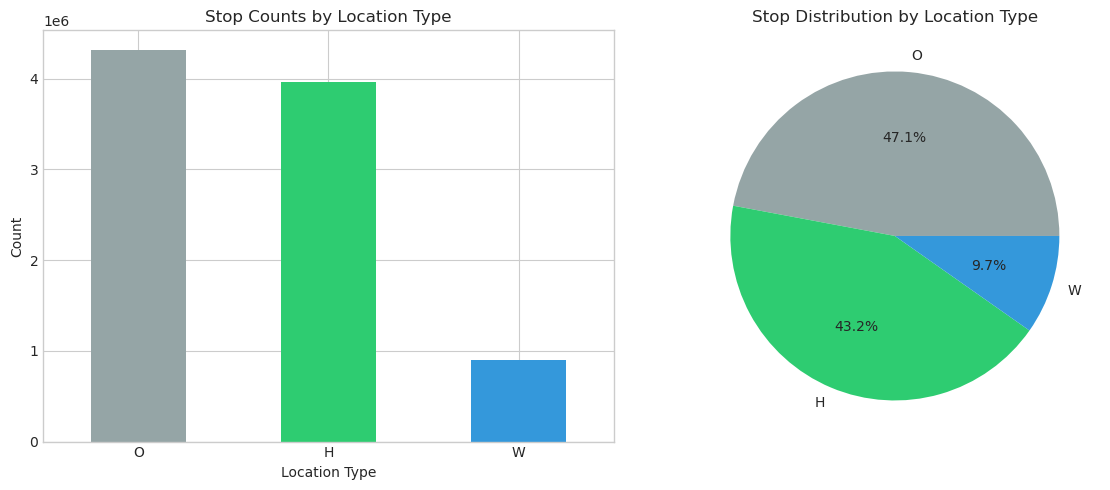

In [5]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = {'H': '#2ecc71', 'W': '#3498db', 'O': '#95a5a6'}
type_counts.plot(kind='bar', ax=axes[0], color=[colors.get(x, '#95a5a6') for x in type_counts.index])
axes[0].set_title('Stop Counts by Location Type')
axes[0].set_xlabel('Location Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=[colors.get(x, '#95a5a6') for x in type_counts.index])
axes[1].set_title('Stop Distribution by Location Type')

plt.tight_layout()
plt.show()

## 3. Detection Rates per Device

In [6]:
# Calculate per-device statistics
device_stats = df.groupby('device_aid').agg(
    n_stops=('loc', 'count'),
    n_home=('location_type', lambda x: (x == 'H').sum()),
    n_work=('location_type', lambda x: (x == 'W').sum()),
    n_other=('location_type', lambda x: (x == 'O').sum()),
    has_home=('location_type', lambda x: (x == 'H').any()),
    has_work=('location_type', lambda x: (x == 'W').any()),
    n_unique_locs=('loc', 'nunique')
).reset_index()

# Detection rates
home_rate = device_stats['has_home'].mean() * 100
work_rate = device_stats['has_work'].mean() * 100
both_rate = (device_stats['has_home'] & device_stats['has_work']).mean() * 100

print("Detection Rates:")
print("="*40)
print(f"  Devices with home detected: {home_rate:.1f}%")
print(f"  Devices with work detected: {work_rate:.1f}%")
print(f"  Devices with both:          {both_rate:.1f}%")
print(f"\nTarget: Home >= 90%, Work >= 50%")
print(f"Status: Home {'PASS' if home_rate >= 90 else 'FAIL'}, Work {'PASS' if work_rate >= 50 else 'OK (may be lower for Sweden)'}")

Detection Rates:
  Devices with home detected: 71.4%
  Devices with work detected: 42.6%
  Devices with both:          42.5%

Target: Home >= 90%, Work >= 50%
Status: Home FAIL, Work OK (may be lower for Sweden)


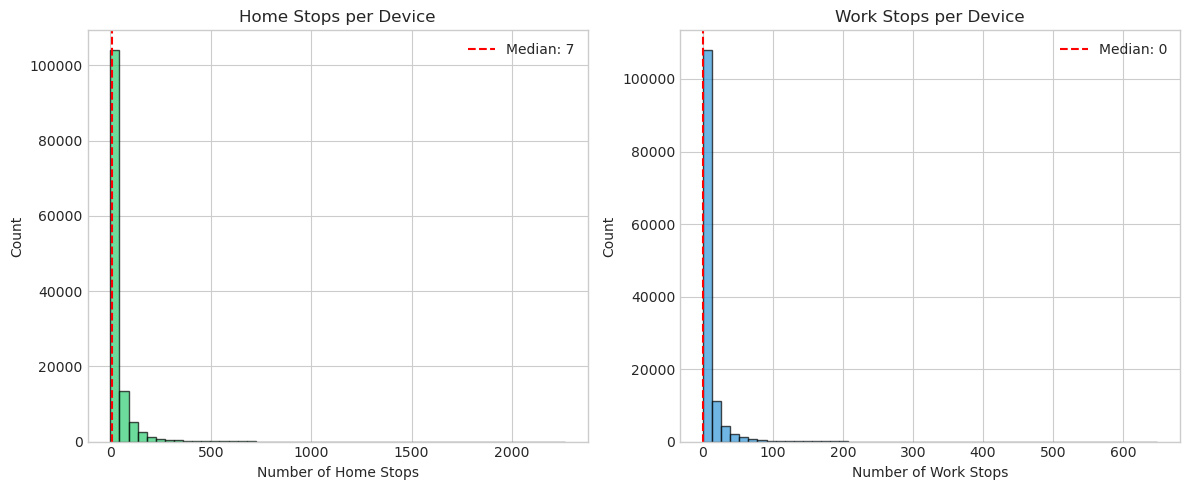

In [7]:
# Distribution of home/work stops per device
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Home stops per device
axes[0].hist(device_stats['n_home'], bins=50, edgecolor='black', alpha=0.7, color='#2ecc71')
axes[0].axvline(device_stats['n_home'].median(), color='red', linestyle='--', label=f"Median: {device_stats['n_home'].median():.0f}")
axes[0].set_title('Home Stops per Device')
axes[0].set_xlabel('Number of Home Stops')
axes[0].set_ylabel('Count')
axes[0].legend()

# Work stops per device
axes[1].hist(device_stats['n_work'], bins=50, edgecolor='black', alpha=0.7, color='#3498db')
axes[1].axvline(device_stats['n_work'].median(), color='red', linestyle='--', label=f"Median: {device_stats['n_work'].median():.0f}")
axes[1].set_title('Work Stops per Device')
axes[1].set_xlabel('Number of Work Stops')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Temporal Patterns

In [8]:
# Convert start time to datetime and extract hour
df['start_dt'] = pd.to_datetime(df['start'], unit='s')
df['hour'] = df['start_dt'].dt.hour
df['weekday'] = df['start_dt'].dt.weekday  # 0=Monday, 6=Sunday
df['is_weekend'] = df['weekday'] >= 5

print("Sample datetime conversion:")
print(df[['start', 'start_dt', 'hour', 'weekday']].head())

Sample datetime conversion:
        start            start_dt  hour  weekday
0  1704153600 2024-01-02 00:00:00     0        1
1  1704460336 2024-01-05 13:12:16    13        4
2  1704499200 2024-01-06 00:00:00     0        5
3  1706140800 2024-01-25 00:00:00     0        3
4  1706659200 2024-01-31 00:00:00     0        2


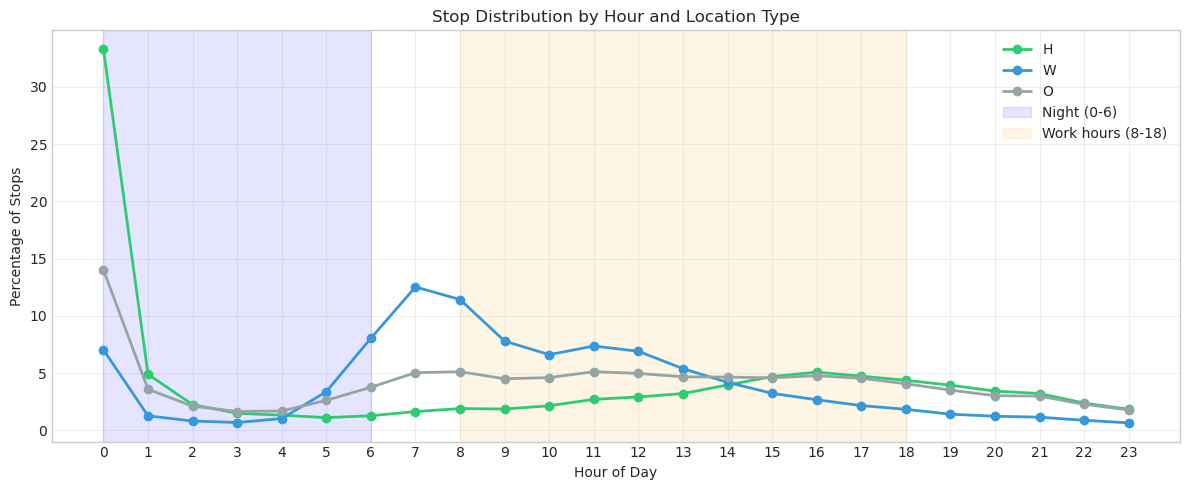

In [9]:
# Hour distribution by location type
fig, ax = plt.subplots(figsize=(12, 5))

for loc_type, color in [('H', '#2ecc71'), ('W', '#3498db'), ('O', '#95a5a6')]:
    subset = df[df['location_type'] == loc_type]
    hour_counts = subset['hour'].value_counts().sort_index()
    hour_pcts = hour_counts / hour_counts.sum() * 100
    ax.plot(hour_pcts.index, hour_pcts.values, marker='o', label=loc_type, color=color, linewidth=2)

ax.axvspan(0, 6, alpha=0.1, color='blue', label='Night (0-6)')
ax.axvspan(8, 18, alpha=0.1, color='orange', label='Work hours (8-18)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Percentage of Stops')
ax.set_title('Stop Distribution by Hour and Location Type')
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

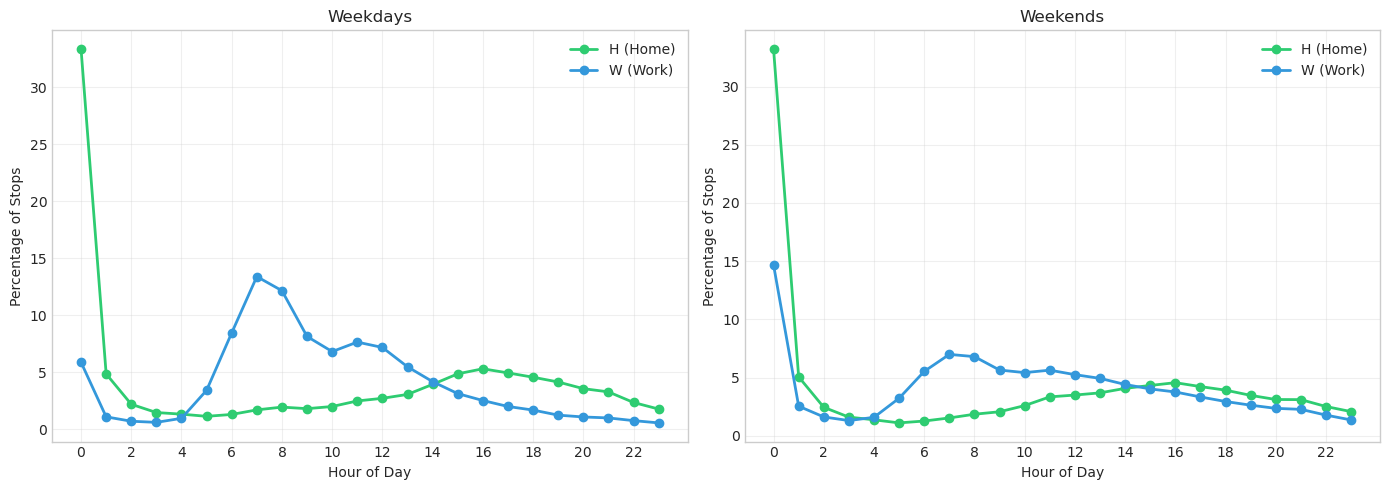


Work stops on weekdays: 774,875
Work stops on weekends: 119,262
Weekend/Weekday ratio: 15.4% (should be low)


In [10]:
# Weekday vs Weekend patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (is_weekend, title) in enumerate([(False, 'Weekdays'), (True, 'Weekends')]):
    subset = df[df['is_weekend'] == is_weekend]
    
    for loc_type, color in [('H', '#2ecc71'), ('W', '#3498db')]:
        loc_subset = subset[subset['location_type'] == loc_type]
        hour_counts = loc_subset['hour'].value_counts().sort_index()
        hour_pcts = hour_counts / hour_counts.sum() * 100
        axes[idx].plot(hour_pcts.index, hour_pcts.values, marker='o', 
                       label=f"{loc_type} ({'Home' if loc_type == 'H' else 'Work'})", 
                       color=color, linewidth=2)
    
    axes[idx].set_xlabel('Hour of Day')
    axes[idx].set_ylabel('Percentage of Stops')
    axes[idx].set_title(f'{title}')
    axes[idx].set_xticks(range(0, 24, 2))
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Work should be much lower on weekends
weekday_work = df[(~df['is_weekend']) & (df['location_type'] == 'W')].shape[0]
weekend_work = df[(df['is_weekend']) & (df['location_type'] == 'W')].shape[0]
print(f"\nWork stops on weekdays: {weekday_work:,}")
print(f"Work stops on weekends: {weekend_work:,}")
print(f"Weekend/Weekday ratio: {weekend_work/weekday_work*100:.1f}% (should be low)")

## 5. Primary Home/Work Locations

In [11]:
# Load primary locations if available
loc_file = HW_DIR / 'home_work_locations.parquet'
if loc_file.exists():
    locations = pd.read_parquet(loc_file)
    print(f"Loaded {len(locations):,} device locations")
    print(f"\nColumns: {locations.columns.tolist()}")
    print(f"\nSample:")
    display(locations.head())
else:
    print("Primary locations not yet extracted. Run:")
    print("  python home_work_detection.py --extract")

Primary locations not yet extracted. Run:
  python home_work_detection.py --extract


## 6. Spatial Distribution

In [12]:
# Sweden bounding box
SWEDEN_BOUNDS = {
    'lat_min': 55.0,
    'lat_max': 69.0,
    'lon_min': 10.0,
    'lon_max': 25.0
}

# Check coordinates
outside_sweden = (
    (df['latitude'] < SWEDEN_BOUNDS['lat_min']) | 
    (df['latitude'] > SWEDEN_BOUNDS['lat_max']) |
    (df['longitude'] < SWEDEN_BOUNDS['lon_min']) | 
    (df['longitude'] > SWEDEN_BOUNDS['lon_max'])
)
print(f"Stops outside Sweden bounds: {outside_sweden.sum():,} ({100*outside_sweden.mean():.2f}%)")

Stops outside Sweden bounds: 652 (0.01%)


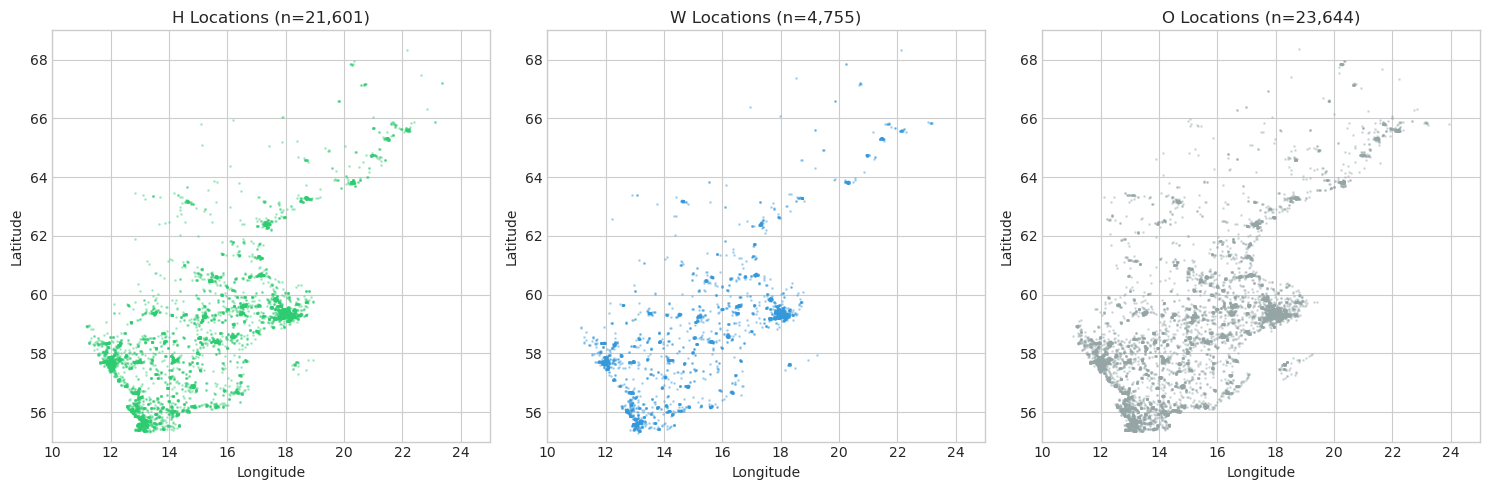

In [13]:
# Spatial scatter plot (sample for performance)
sample = df.sample(n=min(50000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, loc_type in enumerate(['H', 'W', 'O']):
    subset = sample[sample['location_type'] == loc_type]
    axes[idx].scatter(subset['longitude'], subset['latitude'], 
                      alpha=0.3, s=1, c={'H': '#2ecc71', 'W': '#3498db', 'O': '#95a5a6'}[loc_type])
    axes[idx].set_title(f"{loc_type} Locations (n={len(subset):,})")
    axes[idx].set_xlabel('Longitude')
    axes[idx].set_ylabel('Latitude')
    axes[idx].set_xlim(SWEDEN_BOUNDS['lon_min'], SWEDEN_BOUNDS['lon_max'])
    axes[idx].set_ylim(SWEDEN_BOUNDS['lat_min'], SWEDEN_BOUNDS['lat_max'])

plt.tight_layout()
plt.show()

## 7. Sample User Analysis

In [14]:
# Find a user with both home and work detected
good_users = device_stats[
    (device_stats['has_home']) & 
    (device_stats['has_work']) &
    (device_stats['n_stops'] >= 50)
]['device_aid'].values

print(f"Users with home & work and >= 50 stops: {len(good_users):,}")

if len(good_users) > 0:
    sample_user = np.random.choice(good_users)
    user_data = df[df['device_aid'] == sample_user].copy()
    
    print(f"\nSample user: {sample_user[:8]}...")
    print(f"Total stops: {len(user_data)}")
    print(f"\nLocation type distribution:")
    print(user_data['location_type'].value_counts())

Users with home & work and >= 50 stops: 35,888

Sample user: 1c726ceb...
Total stops: 74

Location type distribution:
location_type
O    35
H    32
W     7
Name: count, dtype: int64


In [ ]:
# Visualize sample user's trajectory
if len(good_users) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Spatial plot
    colors = {'H': '#2ecc71', 'W': '#3498db', 'O': '#95a5a6'}
    for loc_type in ['O', 'W', 'H']:  # Plot H last so it's on top
        subset = user_data[user_data['location_type'] == loc_type]
        axes[0].scatter(subset['longitude'], subset['latitude'], 
                        c=colors[loc_type], label=loc_type, 
                        alpha=0.7, s=50 if loc_type in ['H', 'W'] else 20)
    
    axes[0].set_title(f'Sample User Locations')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    axes[0].legend()
    
    # Hourly pattern
    for loc_type in ['H', 'W']:
        subset = user_data[user_data['location_type'] == loc_type]
        if len(subset) > 0:
            hour_counts = subset['hour'].value_counts().sort_index()
            axes[1].plot(hour_counts.index, hour_counts.values, 
                         marker='o', label=loc_type, color=colors[loc_type])
    
    axes[1].set_title('Sample User: Hour of Day Pattern')
    axes[1].set_xlabel('Hour')
    axes[1].set_ylabel('Stop Count')
    axes[1].set_xticks(range(0, 24, 2))
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 8. Data Quality Summary

In [16]:
print("="*60)
print("HOME/WORK DETECTION VALIDATION SUMMARY")
print("="*60)
print(f"\nData Overview:")
print(f"  - Total stops: {len(df):,}")
print(f"  - Total devices: {df['device_aid'].nunique():,}")

print(f"\nLocation Type Distribution:")
for t in ['H', 'W', 'O']:
    if t in type_counts.index:
        print(f"  - {t}: {type_counts[t]:,} ({type_pcts[t]:.1f}%)")

print(f"\nDetection Rates:")
print(f"  - Home: {home_rate:.1f}% (target >= 90%)")
print(f"  - Work: {work_rate:.1f}% (target >= 50%)")
print(f"  - Both: {both_rate:.1f}%")

print(f"\nTemporal Patterns:")
print(f"  - Weekend/Weekday work ratio: {weekend_work/weekday_work*100:.1f}%")

print(f"\nSpatial Quality:")
print(f"  - Stops outside Sweden: {100*outside_sweden.mean():.2f}%")

print(f"\n{'='*60}")
status = "PASS" if home_rate >= 85 and work_rate >= 40 else "REVIEW NEEDED"
print(f"Overall Status: {status}")
print("="*60)

HOME/WORK DETECTION VALIDATION SUMMARY

Data Overview:
  - Total stops: 9,173,381
  - Total devices: 129,004

Location Type Distribution:
  - H: 3,962,680 (43.2%)
  - W: 894,137 (9.7%)
  - O: 4,316,564 (47.1%)

Detection Rates:
  - Home: 71.4% (target >= 90%)
  - Work: 42.6% (target >= 50%)
  - Both: 42.5%

Temporal Patterns:
  - Weekend/Weekday work ratio: 15.4%

Spatial Quality:
  - Stops outside Sweden: 0.01%

Overall Status: REVIEW NEEDED
